# 横向弛豫时间 T₂ 标定 — 光学 FID 时域法

**原理**：RF 开关门控 Pump AOM 产生 Larmor 频率 (≈ 90 kHz) 调制的 Pump 光 Burst，
激发横向自旋相干。Burst 结束后 Pump 光关断，自旋自由进动，
示波器采集 PD 阻尼振荡信号，拟合得 T₂。

**信号链路**：
- DG4000 (DG4E222800868) CH1 → 100 MHz 正弦 CW → RF 开关 IN（AOM 载波）
- DG4000 (DG4E222800868) CH2 → 90 kHz 方波 Burst → RF 开关 CTRL（门控）
- RF 开关 OUT → AOM → 90 kHz 调制 Pump 光
- CH2 同步输出 → 示波器 CH4（触发）
- PDB 输出 → 示波器 CH1（PD 信号采集）

**设备**：GS200 (主磁场) | DG912 Pro (Pump DC + Probe) | DG4000 (AOM载波+门控) | SDS 示波器 | HF2 LIA (监控) | TEC103 (温控)

**参数概览**：
- AOM 载波 (CH1)：100 MHz CW，0.1 V
- RF 门控 (CH2)：90 kHz 方波 Burst，5000 周期 (~55.6 ms)，5 Vpp + 2.5V offset
- 示波器：1 MSa/s，100 ms 窗口，PD=CH1，Trig=CH4（上升沿，1.5V）
- 重复 20 次取平均
- 数据分析：直接拟合阻尼振荡 V(t) = A·exp(-(t-t₀)/T₂)·cos(2πf_L(t-t₀)+φ) + V_DC

In [14]:
from pathlib import Path
import sys
# 自动定位项目根目录（以 params/ 目录为标记）
project_root = Path.cwd()
while not (project_root / "params").exists() and project_root.parent != project_root:
    project_root = project_root.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import numpy as np
import yaml
import time
from datetime import datetime
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# 设备库
from gs200 import GS200Instrument
from signal_generator import DG4000Instrument
from tec_controller import TECInstrument
from lockin_amplifier import HF2Instrument, demod, SignalInputConfig, DemodulatorConfig
from sds_acquisition import SDSInstrument, SDSAcquisition, AcquisitionConfig, ChannelConfig, TriggerConfig

print("导入完成")

导入完成


In [23]:
# ========== 加载配置文件 ==========
with open(project_root / "params" / "mapping.yaml", encoding="utf-8") as f:
    MAPPING = yaml.safe_load(f)["mapping"]

with open(project_root / "params" / "safety_limits.yaml", encoding="utf-8") as f:
    LIMITS = yaml.safe_load(f)["safety_limits"]

# ========== 实验参数 ==========
EXPERIMENT_TYPE = "T2_Calibration"
RUN_TAG = "optical_FID"

# ---- Pump 光 ----
PUMP_POWER = 0.1               # Pump 光 DC 功率 (V)
# ---- RF 开关: AOM 载波 (CH1) ----
AOM_CARRIER_FREQ = 100.0e6     # AOM 载波频率 (Hz)，固定 100 MHz
AOM_CARRIER_AMPLITUDE = 0.1    # AOM 载波幅度 (V)，安全限值 ≤ 0.18V
# ---- RF 开关: 门控脉冲 (CH2) ----
RF_GATE_FREQ = 90000           # 门控脉冲频率 (Hz) = Ω_L/2π，等于 Larmor 进动频率
RF_GATE_AMPLITUDE = 5.0        # 门控脉冲幅度 (Vpp)，5V TTL 电平
RF_GATE_OFFSET = 2.5           # 门控脉冲 DC 偏置 (V)，5Vpp + 2.5V offset = 0~5V
RF_GATE_DUTY = 5.0             # 门控脉冲占空比 (%)，窄脉冲驱动 RF 开关
BURST_NCYCLES = 5000           # Burst 周期数，5000/90000 ≈ 55.6 ms
BURST_PERIOD = 0.1             # Burst 触发周期 (s)，两次触发间最小间隔

# ---- Probe 光 ----
PROBE_POWER = 0.1              # Probe 光功率 (V)，CW 常开

# ---- 主磁场 ----
MAIN_FIELD_mA = 9.30           # 主磁场 (mA)，Ω_L/2π ≈ 90 kHz

# ---- 示波器通道选择 ----
SCOPE_PD_CHANNEL = 1           # PD 信号输入通道 (PDB 输出 → CH1)
SCOPE_TRIG_CHANNEL = 4         # 触发信号输入通道 (DG4000 同步输出 → CH4)
SCOPE_TRIG_SOURCE = f"C{SCOPE_TRIG_CHANNEL}"  # 触发源
SCOPE_TRIG_SLOPE = "FALLing"   # 下降沿触发：同步信号下降沿 = Burst 结束，t=0 即 FID 起点
# ---- 示波器采集 ----
SCOPE_SAMPLE_RATE = 1.0e6      # 采样率 (Sa/s)
SCOPE_DURATION = 0.05          # 采集时长 (s)，Burst 结束后纯 FID 衰减段
ACQ_REPEATS = 5               # 重复次数

# ---- LIA 监控 ----
HF2_DEMOD_IDX = 1              # 解调器索引
HF2_OSC_FREQ = 90000           # 振荡器频率 (Hz)
HF2_SIGNAL_RANGE = 2.0         # 信号输入量程 (V)
HF2_DEMOD_TC = 0.001           # 解调时间常数 (s)
HF2_DEMOD_ORDER = 4            # 滤波器阶数
HF2_DEMOD_RATE = 10000         # 数据速率 (Sa/s)

# ---- 温度 ----
TEC_TEMPERATURE = 100.0        # 气室温度 (°C)

# 计算值
BURST_DURATION = BURST_NCYCLES / RF_GATE_FREQ  # ≈ 0.0556 s
SCOPE_TOTAL_POINTS = int(SCOPE_SAMPLE_RATE * SCOPE_DURATION)

# ========== 安全边界检查 ==========
def validate_safety_limit(name, value):
    lim = LIMITS.get(name)
    if lim is None:
        return value
    lo, hi = lim["min"], lim["max"]
    if value < lo or value > hi:
        raise ValueError(f"[安全拦截] {name}={value} 超出范围 [{lo}, {hi}]")
    return value

validate_safety_limit("Pump_laser_power", PUMP_POWER)
validate_safety_limit("Probe_laser_power", PROBE_POWER)
validate_safety_limit("main_magnetic_field", MAIN_FIELD_mA)
validate_safety_limit("Pump_modulation", AOM_CARRIER_AMPLITUDE)
validate_safety_limit("Time_sequence", RF_GATE_AMPLITUDE)
validate_safety_limit("temperature", TEC_TEMPERATURE)

print(f"AOM 载波: {AOM_CARRIER_FREQ/1e6:.0f} MHz, {AOM_CARRIER_AMPLITUDE} V")
print(f"RF 门控: {RF_GATE_FREQ} Hz 脉冲, {RF_GATE_DUTY}% 占空比, "
      f"{BURST_NCYCLES} cycles, Burst 时长 {BURST_DURATION*1000:.1f} ms, 周期 {BURST_PERIOD*1000:.0f} ms")
print(f"示波器: PD=CH{SCOPE_PD_CHANNEL}, Trig={SCOPE_TRIG_SOURCE} {SCOPE_TRIG_SLOPE}, "
      f"{SCOPE_SAMPLE_RATE/1e3:.0f} kSa/s, {SCOPE_DURATION*1000:.0f} ms, {SCOPE_TOTAL_POINTS} 点")
print("安全限值检查通过")

AOM 载波: 100 MHz, 0.1 V
RF 门控: 90000 Hz 脉冲, 5.0% 占空比, 5000 cycles, Burst 时长 55.6 ms, 周期 100 ms
示波器: PD=CH1, Trig=C4 FALLing, 1000 kSa/s, 50 ms, 50000 点
安全限值检查通过


In [24]:
# ========== 连接设备 ==========
devices = {}

try:
    # ---- GS200: 主磁场 ----
    gs200_cfg = MAPPING["main_magnetic_field"]
    gs200 = GS200Instrument(gs200_cfg["resource"])
    gs200.connect()
    gs200.set_current_limit(0.015)  # 硬件限流 15 mA
    devices["gs200"] = gs200
    print(f"GS200 已连接: {gs200.idn()}")

    # ---- DG912 Pro: Pump DC + Probe 光 (同一设备, 不同通道) ----
    pump_cfg = MAPPING["Pump_laser_power"]
    probe_cfg = MAPPING["Probe_laser_power"]
    assert pump_cfg["resource"] == probe_cfg["resource"], "Pump/Probe 不在同一台 DG912"

    PUMP_DC_CH = pump_cfg["channel"]
    PROBE_CH = probe_cfg["channel"]
    dg_laser = DG4000Instrument(pump_cfg["resource"])
    dg_laser.connect()
    devices["dg_laser"] = dg_laser
    print(f"DG912 Pro 已连接: Pump CH{PUMP_DC_CH}, Probe CH{PROBE_CH}")

    # ---- DG4000 (DG4E222800868): AOM 载波 + RF 开关门控 (同一设备, 双通道) ----
    # CH1: 100 MHz 正弦 CW → RF 开关 IN → AOM 驱动载波
    # CH2: 90 kHz 脉冲 Burst → RF 开关 CTRL → 门控 100 MHz 通断
    #      同步输出 → 示波器 EXT TRIG
    pump_mod_cfg = MAPPING["Pump_modulation"]
    time_seq_cfg = MAPPING["Time_sequence"]
    assert pump_mod_cfg["resource"] == time_seq_cfg["resource"], \
        "Pump_modulation/Time_sequence 不在同一台 DG4000"

    AOM_CARRIER_CH = pump_mod_cfg["channel"]   # CH1: 100 MHz 载波
    RF_GATE_CH = time_seq_cfg["channel"]        # CH2: 90 kHz 门控
    dg_rf_switch = DG4000Instrument(pump_mod_cfg["resource"])
    dg_rf_switch.connect()
    devices["dg_rf_switch"] = dg_rf_switch
    print(f"DG4000 RF 开关已连接: AOM载波 CH{AOM_CARRIER_CH}, 门控 CH{RF_GATE_CH}")
    # ---- Temp_Switch ----
    temp_sw_cfg = MAPPING.get("Temp_Switch")
    dg_temp_sw = DG4000Instrument(temp_sw_cfg["resource"], channel=temp_sw_cfg["channel"])
    dg_temp_sw.connect()
    devices["dg_temp_sw"] = dg_temp_sw
    print(f"Temp_Switch 已连接: {temp_sw_cfg['resource']}")
    # ---- SDS 示波器 ----
    scope_cfg = MAPPING["scope_waveform"]
    sds_inst = SDSInstrument(scope_cfg["resource"])
    sds_inst.connect()
    acquirer = SDSAcquisition(sds_inst)
    devices["sds_inst"] = sds_inst
    devices["acquirer"] = acquirer
    print(f"SDS 示波器已连接: {sds_inst.idn()}")

    # ---- HF2 LIA (监控) ----
    lia_cfg = MAPPING["lockin_xy"]
    hfi = HF2Instrument(
        host=lia_cfg["host"], port=lia_cfg["port"],
        api_level=1, device_id=lia_cfg["device_id"],
    )
    hfi.connect()
    devices["hfi"] = hfi
    print(f"HF2 LIA 已连接: {lia_cfg['device_id']}")

    # ---- TEC103 温控器 ----
    tec_cfg = MAPPING["temperature"]
    tec = TECInstrument(port=tec_cfg["resource"])
    tec.connect()
    devices["tec"] = tec
    print(f"TEC103 已连接: {tec_cfg['resource']}")

except Exception as e:
    print(f"设备连接失败: {e}")
    for name, dev in devices.items():
        try:
            if hasattr(dev, "disconnect"):
                dev.disconnect()
        except Exception:
            pass
    raise

print("\n所有设备连接成功")

GS200 已连接: YOKOGAWA,GS210,90Z631552,2.02
DG912 Pro 已连接: Pump CH1, Probe CH2
DG4000 RF 开关已连接: AOM载波 CH1, 门控 CH2
Temp_Switch 已连接: USB0::0x1AB1::0x0646::DG9Q271200104::INSTR
SDS 示波器已连接: Siglent Technologies,SDS1204X HD,SDSEV82X900704,6.9.12.1.1.3.8
HF2 LIA 已连接: dev18246
TEC103 已连接: COM3

所有设备连接成功


In [25]:
# ========== 设置初始值 & 创建运行目录 ==========

# 创建运行目录
timestamp = datetime.now().strftime("%m%d_%H%M")
run_dir = project_root / "data" / EXPERIMENT_TYPE / f"{timestamp}_{RUN_TAG}"
run_dir.mkdir(parents=True, exist_ok=True)
(raw_dir := run_dir / "raw").mkdir(exist_ok=True)
(results_dir := run_dir / "results").mkdir(exist_ok=True)
print(f"运行目录: {run_dir}")

# ---- 温控 ----
tec = devices["tec"]
tec.set_target_temperature(TEC_TEMPERATURE, channel=1)
tec.set_enable(True, channel=1)
print(f"TEC 目标温度: {TEC_TEMPERATURE} °C")

print("等待温度稳定...")
time.sleep(5)
current_temp = tec.get_temperature(channel=1)
print(f"当前温度: {current_temp:.1f} °C")

# ---- 主磁场 ----
gs200 = devices["gs200"]
gs200.set_current(MAIN_FIELD_mA / 1000.0)  # mA → A
gs200.set_output(True)
print(f"主磁场: {MAIN_FIELD_mA:.3f} mA")

# ---- Pump DC 光 + Probe 光 ----
dg_laser = devices["dg_laser"]
dg_laser.setup_dc(PUMP_POWER, channel=PUMP_DC_CH)
print(f"Pump DC 光: {PUMP_POWER} V (CH{PUMP_DC_CH})")
dg_laser.setup_dc(PROBE_POWER, channel=PROBE_CH)
print(f"Probe 光 (CW): {PROBE_POWER} V (CH{PROBE_CH})")

# ---- RF 开关: CH1 AOM 载波 (100 MHz CW，持续输出) ----
dg_rf_switch = devices["dg_rf_switch"]
dg_rf_switch.setup_sine(AOM_CARRIER_FREQ, AOM_CARRIER_AMPLITUDE, offset=0.0,
                         channel=AOM_CARRIER_CH)
print(f"AOM 载波: {AOM_CARRIER_FREQ/1e6:.0f} MHz CW, {AOM_CARRIER_AMPLITUDE} V (CH{AOM_CARRIER_CH})")

# ---- LIA 监控设置 ----
hfi = devices["hfi"]
sig_cfg = SignalInputConfig(
    input_index=0, range=HF2_SIGNAL_RANGE,
    ac_coupling=True, diff=False, impedance=50,
)
demod.configure_signal_input(hfi, sig_cfg)

demod_cfg = DemodulatorConfig(
    demod_index=HF2_DEMOD_IDX, enable=True,
    rate=HF2_DEMOD_RATE, input_channel=0, osc_select=0,
    harmonic=1, time_constant=HF2_DEMOD_TC, order=HF2_DEMOD_ORDER,
    phase=0.0,
)
demod.configure_demodulator(hfi, demod_cfg)
hfi.set_double(f"{hfi.osc_path(0)}/freq", HF2_OSC_FREQ)
hfi.sync()
print(f"LIA 监控: demod {HF2_DEMOD_IDX}, osc {HF2_OSC_FREQ} Hz, TC {HF2_DEMOD_TC} s")

print("\n初始值设置完成")

运行目录: d:\Code\exp_agent\data\T2_Calibration\0529_1050_optical_FID
TEC 目标温度: 100.0 °C
等待温度稳定...
当前温度: 100.0 °C
主磁场: 9.300 mA
Pump DC 光: 0.1 V (CH1)
Probe 光 (CW): 0.1 V (CH2)
AOM 载波: 100 MHz CW, 0.1 V (CH1)
LIA 监控: demod 1, osc 90000 Hz, TC 0.001 s

初始值设置完成


In [ ]:
# ========== 配置 RF 门控 Burst + 示波器，执行 FID 采集 ==========

dg_rf_switch = devices["dg_rf_switch"]

# ---- CH2: 90 kHz 脉冲 Burst (RF 开关门控) ----
# CH1 (100 MHz 载波) 已在 Cell 4 中设为 CW 持续输出
# CH2 输出 90 kHz 窄脉冲 (5% 占空比) → RF 开关 CTRL → 门控 100 MHz 通断
# 下降沿同步输出 → 示波器 CH4 下降沿触发 → t=0 = Burst 结束 → 纯 FID 衰减
# [经验] 门控频率必须精确等于 Ω_L/2π，频率偏差导致 FID 拍频
dg_rf_switch.apply_wave("PULSe", freq=RF_GATE_FREQ, amp=RF_GATE_AMPLITUDE,
                         offset=RF_GATE_OFFSET, channel=RF_GATE_CH)
dg_rf_switch.set_pulse_dcycle(RF_GATE_DUTY, channel=RF_GATE_CH)  # 5% 窄脉冲

# [经验] Burst 模式手动触发，周期 100 ms 防止重叠
dg_rf_switch.set_burst_mode("TRIGgered", channel=RF_GATE_CH)
dg_rf_switch.set_burst_ncycles(BURST_NCYCLES, channel=RF_GATE_CH)
dg_rf_switch.set_burst_period(BURST_PERIOD, channel=RF_GATE_CH)
dg_rf_switch.set_burst_trigger_source("INTernal", channel=RF_GATE_CH)
dg_rf_switch.set_burst_state(True, channel=RF_GATE_CH)
dg_rf_switch.set_sync_state(True, channel=RF_GATE_CH)
dg_rf_switch.set_output(True, channel=RF_GATE_CH)
print(f"RF 门控 Burst: {RF_GATE_FREQ} Hz PULSe {RF_GATE_DUTY}%, {BURST_NCYCLES} cycles, "
      f"周期 {BURST_PERIOD*1000:.0f} ms, 同步输出 → CH{SCOPE_TRIG_CHANNEL}")

# ---- 配置示波器 ----
sds_inst = devices["sds_inst"]
acquirer = devices["acquirer"]

# 动态构建通道列表：PD 通道 + 触发通道启用
scope_channels = []
for ch_num in [1, 2, 3, 4]:
    if ch_num == SCOPE_PD_CHANNEL:
        scope_channels.append(ChannelConfig(
            number=ch_num, enabled=True, scale=0.5, offset=0.0,
            coupling="DC", impedance="ONEMeg", probe=1.0,
        ))
    elif ch_num == SCOPE_TRIG_CHANNEL:
        scope_channels.append(ChannelConfig(
            number=ch_num, enabled=True, scale=2.0, offset=2.5,
            coupling="DC", impedance="ONEMeg", probe=1.0,
        ))
    else:
        scope_channels.append(ChannelConfig(number=ch_num, enabled=False))

scope_cfg = AcquisitionConfig(
    sampling_rate=SCOPE_SAMPLE_RATE,
    sampling_time=SCOPE_DURATION,
    acquire_type="NORMal",
    acquire_delay=0.5,
    channels=scope_channels,
    trigger=TriggerConfig(
        mode="NORMal",
        source=SCOPE_TRIG_SOURCE,
        type="EDGE",
        slope=SCOPE_TRIG_SLOPE,
        level=1.5,
    ),
)
print(f"示波器: {SCOPE_SAMPLE_RATE/1e3:.0f} kSa/s, {SCOPE_DURATION*1000:.0f} ms, "
      f"PD=CH{SCOPE_PD_CHANNEL}, Trig={SCOPE_TRIG_SOURCE} {SCOPE_TRIG_SLOPE}")


# ---- 初始配置示波器 ----
acquirer.apply_config(scope_cfg)
# [经验] apply_config 不设存储深度，示波器默认 10K 点。手动设 ≥ SCOPE_TOTAL_POINTS
sds_inst.set_memory_depth("100K")  # 100K ≥ 50000
time.sleep(0.1)
actual_pts = int(sds_inst.get_actual_points())
print(f"示波器存储深度: 100K, 实际采集 {actual_pts} 点 (期望 ≥ {SCOPE_TOTAL_POINTS})")
time.sleep(0.2)

# ---- 重复采集 ----
all_waveforms = []
all_times = []

for i in range(ACQ_REPEATS):

    dg_temp_sw.set_output(False)
    time.sleep(0.5)

    # 等待触发
    if not sds_inst.wait_for_trigger(timeout=10.0):
        print(f"  第 {i+1} 次触发超时，跳过")
        continue
    time.sleep(scope_cfg.acquire_delay)
    sds_inst.trigger_stop()

    # 读取 PD 通道波形
    result = acquirer.acquire_channel(
        SCOPE_PD_CHANNEL, scope_cfg.timebase_scale, scope_cfg.horizontal_divisions,
        trim_points=SCOPE_TOTAL_POINTS,
    )

    dg_temp_sw.set_output(False)
    time.sleep(2)

    all_waveforms.append(result.voltage)
    all_times.append(result.time)

    if i == 0:
        time_axis = result.time

    vpp = result.voltage.max() - result.voltage.min()
    print(f"采集 {i+1}/{ACQ_REPEATS}: {len(result.voltage)} 点, Vpp={vpp:.3f} V", end="")
    try:
        sample = demod.read_demod_sample(hfi, HF2_DEMOD_IDX)
        print(f", LIA R={sample['r']:.4f} V", end="")
    except Exception:
        pass
    print()


# ---- 关断 Burst 模式 ----
dg_rf_switch.set_burst_state(False, channel=RF_GATE_CH)
print("RF 门控 Burst 已关断")

# ---- 保存原始数据（仅保留 t >= 0 的 FID 段） ----
# 下降沿触发点在屏幕中央，时间轴前半段为负（触发前），后半段为 FID
waveforms_array = np.array(all_waveforms)
mask_t0 = time_axis >= 0  # 只取触发点之后的数据
time_fid = time_axis[mask_t0]
waveforms_fid = waveforms_array[:, mask_t0]
avg_waveform = np.mean(waveforms_fid, axis=0)

print(f"触发前丢弃: {np.sum(~mask_t0)} 点, FID 段: {np.sum(mask_t0)} 点 "
      f"({time_fid[0]*1000:.2f} ~ {time_fid[-1]*1000:.1f} ms)")

np.savez(
    raw_dir / "fid_waveforms.npz",
    waveforms=waveforms_fid,
    avg_waveform=avg_waveform,
    time=time_fid,
    sample_rate=SCOPE_SAMPLE_RATE,
    burst_duration=BURST_DURATION,
    rf_gate_freq=RF_GATE_FREQ,
    rf_gate_duty=RF_GATE_DUTY,
    trigger_slope=SCOPE_TRIG_SLOPE,
    acq_repeats=ACQ_REPEATS,
    pd_channel=SCOPE_PD_CHANNEL,
    trig_channel=SCOPE_TRIG_CHANNEL,
)
print(f"原始数据已保存: {raw_dir / 'fid_waveforms.npz'}")
print(f"波形矩阵: {waveforms_fid.shape}, 平均波形点数: {len(avg_waveform)}")


RF 门控 Burst: 90000 Hz PULSe 5.0%, 5000 cycles, 周期 100 ms, 同步输出 → CH4
示波器: 1000 kSa/s, 50 ms, PD=CH1, Trig=C4 FALLing
Temp_Switch 已关闭
示波器存储深度: 100K, 实际采集 50000 点 (期望 ≥ 50000)
采集 1/20: 50000 点, Vpp=0.264 V, LIA R=0.0000 V
采集 2/20: 50000 点, Vpp=0.267 V, LIA R=0.0000 V
采集 3/20: 50000 点, Vpp=0.264 V, LIA R=0.0404 V
采集 4/20: 50000 点, Vpp=0.266 V, LIA R=0.0000 V
采集 5/20: 50000 点, Vpp=0.263 V, LIA R=0.0000 V
采集 6/20: 50000 点, Vpp=0.265 V, LIA R=0.0000 V
采集 7/20: 50000 点, Vpp=0.264 V, LIA R=0.0000 V
采集 8/20: 50000 点, Vpp=0.265 V, LIA R=0.0000 V
采集 9/20: 50000 点, Vpp=0.263 V, LIA R=0.0000 V
采集 10/20: 50000 点, Vpp=0.265 V, LIA R=0.0000 V
采集 11/20: 50000 点, Vpp=0.265 V, LIA R=0.0001 V
采集 12/20: 50000 点, Vpp=0.268 V, LIA R=0.0000 V
采集 13/20: 50000 点, Vpp=0.267 V, LIA R=0.0000 V
采集 14/20: 50000 点, Vpp=0.266 V, LIA R=0.0000 V
采集 15/20: 50000 点, Vpp=0.267 V, LIA R=0.0000 V
采集 16/20: 50000 点, Vpp=0.265 V, LIA R=0.0000 V
采集 17/20: 50000 点, Vpp=0.267 V, LIA R=0.0000 V
采集 18/20: 50000 点, Vpp=0.264 V, LIA 

使用内存中的数据
时间轴: 50000 点, -25.000 ~ 25.0 ms
触发边沿: FALLing
FID 起点 t₀ = 0.0 ms (相对触发点)
FID 段: 50000 点, 时长 25.0 ms

初始猜测: A=0.1242, T₂=3.00 ms, f_L=90000 Hz, offset=0.0158

拟合结果:
  A      = 0.0539 V
  T₂     = 21.613 ± 0.099 ms
  f_L    = 90000.5 Hz  (设定 90000 Hz, 偏差 0.5 Hz)
  φ      = -1.173 rad (-67.2°)
  offset = 0.0156 V


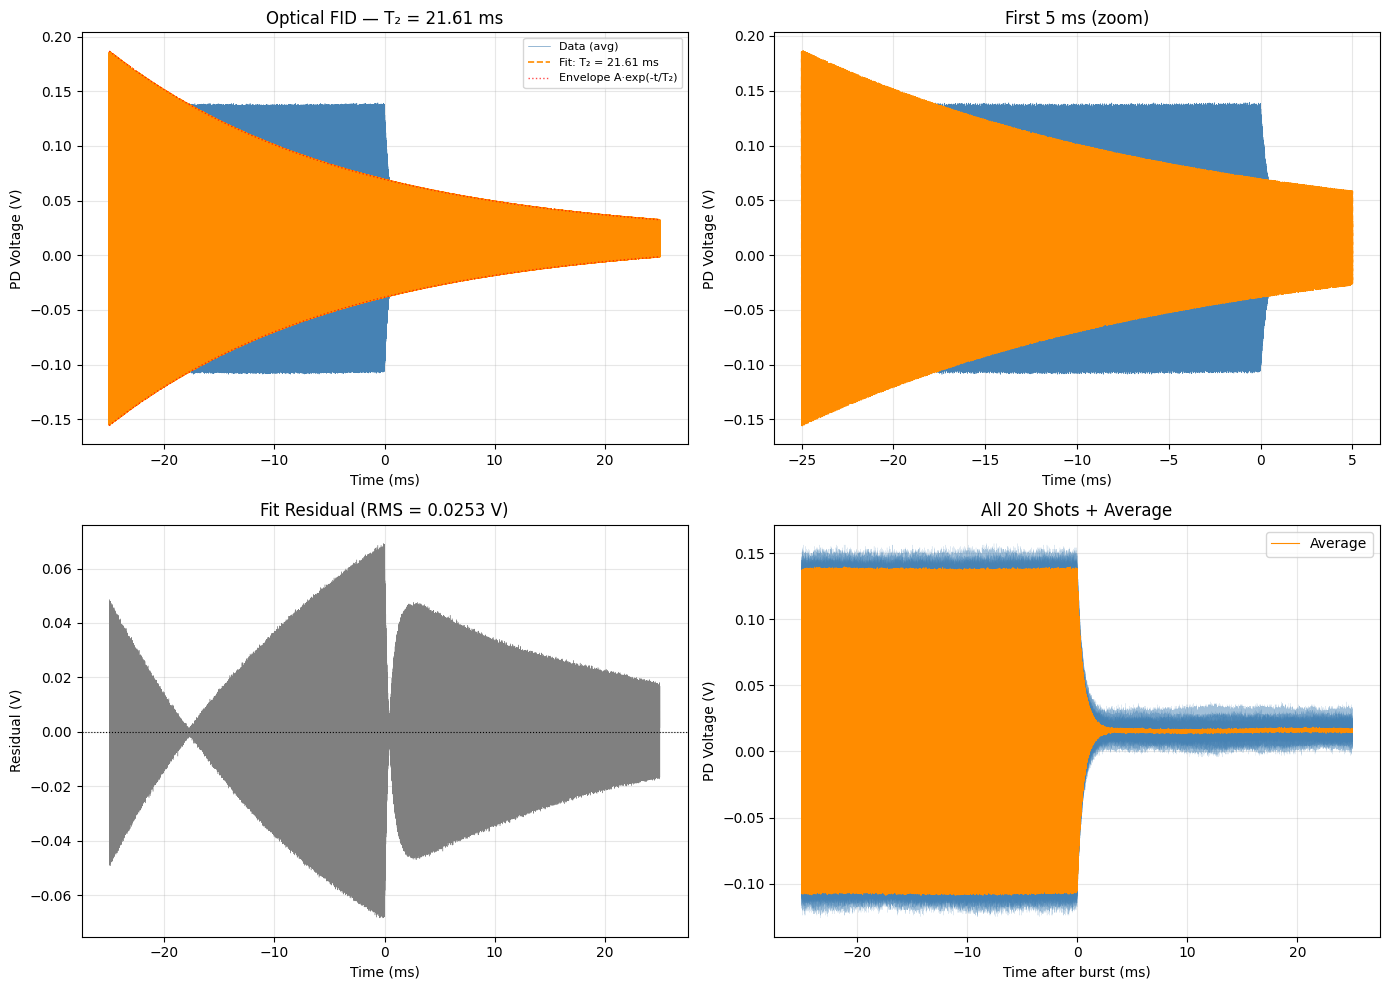

拟合结果已保存: d:\Code\exp_agent\data\T2_Calibration\0529_1050_optical_FID\results\T2_results.yaml

>>> T₂ = 21.613 ± 0.099 ms


In [27]:
# ========== 数据分析：阻尼振荡拟合提取 T₂ ==========

# 加载数据（优先从文件）
data_path = raw_dir / "fid_waveforms.npz"
if data_path.exists():
    loaded = np.load(data_path)
    avg_waveform = loaded["avg_waveform"]
    time_axis = loaded["time"]
    SCOPE_SAMPLE_RATE = float(loaded["sample_rate"])
    RF_GATE_FREQ = float(loaded["rf_gate_freq"])
    TRIGGER_SLOPE = str(loaded.get("trigger_slope", "RISing"))
    BURST_DURATION = float(loaded.get("burst_duration", 0.0))
    print(f"从 {data_path} 加载数据")
else:
    print("使用内存中的数据")
    TRIGGER_SLOPE = SCOPE_TRIG_SLOPE

print(f"时间轴: {len(time_axis)} 点, {time_axis[0]*1000:.3f} ~ {time_axis[-1]*1000:.1f} ms")
print(f"触发边沿: {TRIGGER_SLOPE}")

# ---- 确定 FID 起点 ----
# 下降沿触发：t=0 = Burst 结束，整段波形为 FID 衰减
# 上升沿触发：需跳过 Burst，t > BURST_DURATION 才是 FID
if TRIGGER_SLOPE == "FALLing":
    t0 = 0.0
    t_fid = time_axis
    v_fid = avg_waveform
else:
    t0 = BURST_DURATION
    mask = time_axis > t0
    t_fid = time_axis[mask] - t0
    v_fid = avg_waveform[mask]

print(f"FID 起点 t₀ = {t0*1000:.1f} ms (相对触发点)")
print(f"FID 段: {len(t_fid)} 点, 时长 {t_fid[-1]*1000:.1f} ms")

# ---- 阻尼振荡拟合模型 ----
def damped_oscillation(t, A, T2, f_L, phi, offset):
    """V(t) = A * exp(-t/T2) * cos(2π·f_L·t + φ) + offset"""
    return A * np.exp(-t / T2) * np.cos(2 * np.pi * f_L * t + phi) + offset

# 初始猜测
A_guess = (v_fid.max() - v_fid.min()) / 2
T2_guess = 0.003                                # 3 ms
f_L_guess = RF_GATE_FREQ
phi_guess = 0.0
offset_guess = np.mean(v_fid[-500:]) if len(v_fid) > 500 else np.mean(v_fid)

p0 = [A_guess, T2_guess, f_L_guess, phi_guess, offset_guess]
print(f"\n初始猜测: A={A_guess:.4f}, T₂={T2_guess*1000:.2f} ms, "
      f"f_L={f_L_guess:.0f} Hz, offset={offset_guess:.4f}")

# 非线性拟合
try:
    popt, pcov = curve_fit(
        damped_oscillation, t_fid, v_fid, p0=p0,
        bounds=(
            [0, 1e-6, RF_GATE_FREQ * 0.95, -np.pi, -1.0],
            [A_guess * 5, 0.1, RF_GATE_FREQ * 1.05, np.pi, 1.0],
        ),
        maxfev=20000,
    )
    A_fit, T2_fit, f_L_fit, phi_fit, offset_fit = popt
    T2_err = np.sqrt(pcov[1, 1]) if pcov[1, 1] > 0 else 0.0

    print(f"\n拟合结果:")
    print(f"  A      = {A_fit:.4f} V")
    print(f"  T₂     = {T2_fit*1000:.3f} ± {T2_err*1000:.3f} ms")
    print(f"  f_L    = {f_L_fit:.1f} Hz  (设定 {RF_GATE_FREQ} Hz, 偏差 {f_L_fit-RF_GATE_FREQ:.1f} Hz)")
    print(f"  φ      = {phi_fit:.3f} rad ({np.degrees(phi_fit):.1f}°)")
    print(f"  offset = {offset_fit:.4f} V")

    fit_success = True
except Exception as e:
    print(f"拟合失败: {e}")
    fit_success = False
    A_fit, T2_fit, f_L_fit, phi_fit, offset_fit = p0
    T2_err = 0.0

# ---- 绘图 ----
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# (a) 全时域波形 + 拟合包络
ax = axes[0, 0]
ax.plot(t_fid * 1000, v_fid, linewidth=0.4, color='steelblue', label='Data (avg)')
if fit_success:
    v_fit = damped_oscillation(t_fid, *popt)
    ax.plot(t_fid * 1000, v_fit, '--', linewidth=1.2, color='darkorange',
            label=f'Fit: T₂ = {T2_fit*1000:.2f} ms')
    # 叠加包络线
    envelope = A_fit * np.exp(-t_fid / T2_fit) + offset_fit
    ax.plot(t_fid * 1000, envelope, ':', linewidth=1.0, color='red', alpha=0.7,
            label=f'Envelope A·exp(-t/T₂)')
    ax.plot(t_fid * 1000, -A_fit * np.exp(-t_fid / T2_fit) + offset_fit,
            ':', linewidth=1.0, color='red', alpha=0.7)
ax.set_xlabel('Time (ms)')
ax.set_ylabel('PD Voltage (V)')
ax.set_title(f'Optical FID — T₂ = {T2_fit*1000:.2f} ms')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# (b) 初始段放大 (前 5 ms)
ax = axes[0, 1]
zoom_end = min(0.005, t_fid[-1])
mask_zoom = t_fid <= zoom_end
ax.plot(t_fid[mask_zoom] * 1000, v_fid[mask_zoom], linewidth=0.4, color='steelblue')
if fit_success:
    ax.plot(t_fid[mask_zoom] * 1000, damped_oscillation(t_fid[mask_zoom], *popt),
            '--', linewidth=1.2, color='darkorange')
ax.set_xlabel('Time (ms)')
ax.set_ylabel('PD Voltage (V)')
ax.set_title(f'First {zoom_end*1000:.0f} ms (zoom)')
ax.grid(True, alpha=0.3)

# (c) 拟合残差
ax = axes[1, 0]
if fit_success:
    residual = v_fid - damped_oscillation(t_fid, *popt)
    ax.plot(t_fid * 1000, residual, linewidth=0.3, color='gray')
    ax.axhline(y=0, color='black', linestyle=':', linewidth=0.8)
    ax.set_xlabel('Time (ms)')
    ax.set_ylabel('Residual (V)')
    ax.set_title(f'Fit Residual (RMS = {np.std(residual):.4f} V)')
    ax.grid(True, alpha=0.3)

# (d) 叠加所有单次波形
ax = axes[1, 1]
waveforms_array = loaded["waveforms"] if data_path.exists() else np.array(all_waveforms)
n_show = min(waveforms_array.shape[0], 20)
for j in range(n_show):
    if TRIGGER_SLOPE == "FALLing":
        wf = waveforms_array[j]
        t_wf = time_axis
    else:
        wf = waveforms_array[j][time_axis > BURST_DURATION]
        t_wf = (time_axis[time_axis > BURST_DURATION] - BURST_DURATION)
    ax.plot(t_wf * 1000, wf, linewidth=0.12, alpha=0.5, color='steelblue')
# 平均波形
if TRIGGER_SLOPE == "FALLing":
    ax.plot(time_axis * 1000, avg_waveform, linewidth=0.8, color='darkorange', label='Average')
else:
    ax.plot((time_axis[time_axis > BURST_DURATION] - BURST_DURATION) * 1000,
            avg_waveform[time_axis > BURST_DURATION], linewidth=0.8, color='darkorange', label='Average')
ax.set_xlabel('Time after burst (ms)')
ax.set_ylabel('PD Voltage (V)')
ax.set_title(f'All {int(n_show)} Shots + Average')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
fig.savefig(results_dir / "T2_fid_analysis.png", dpi=150, bbox_inches='tight')
plt.show()

# ---- 保存拟合结果 ----
if fit_success:
    results = {
        "method": "optical_FID",
        "trigger_slope": TRIGGER_SLOPE,
        "T2_s": float(T2_fit),
        "T2_ms": float(T2_fit * 1000),
        "T2_err_ms": float(T2_err * 1000),
        "f_L_fit_Hz": float(f_L_fit),
        "f_L_set_Hz": float(RF_GATE_FREQ),
        "f_L_deviation_Hz": float(f_L_fit - RF_GATE_FREQ),
        "amplitude_V": float(A_fit),
        "phase_rad": float(phi_fit),
        "offset_V": float(offset_fit),
        "burst_duration_ms": float(BURST_DURATION * 1000),
        "acq_repeats": ACQ_REPEATS,
        "sample_rate_Hz": float(SCOPE_SAMPLE_RATE),
        "pump_power_V": PUMP_POWER,
        "probe_power_V": PROBE_POWER,
        "main_field_mA": MAIN_FIELD_mA,
        "temperature_C": TEC_TEMPERATURE,
    }
    with open(results_dir / "T2_results.yaml", "w", encoding="utf-8") as f:
        yaml.dump(results, f, default_flow_style=False, allow_unicode=True)
    print(f"拟合结果已保存: {results_dir / 'T2_results.yaml'}")
    print(f"\n>>> T₂ = {T2_fit*1000:.3f} ± {T2_err*1000:.3f} ms")

In [28]:
# ========== 安全断开 ==========

print("正在断开设备...")
print("（所有设备输出状态保持当前设置不变）")

for name, dev in devices.items():
    if hasattr(dev, "disconnect"):
        try:
            dev.disconnect()
            print(f"  {name} 已断开")
        except Exception as e:
            print(f"  {name} 断开失败: {e}")

print("所有设备已断开")

正在断开设备...
（所有设备输出状态保持当前设置不变）
  gs200 已断开
  dg_laser 已断开
  dg_rf_switch 已断开
  dg_temp_sw 已断开
  sds_inst 已断开
  hfi 已断开
  tec 已断开
所有设备已断开
